# MIA Seed-Stability Check — CTGAN

Your reported CTGAN result (MIA AUC decreasing ~0.02–0.03 as ε drops from
10→1) came from a single evaluation run per combo. This notebook re-runs
`MIAEvaluator.evaluate()` several times per combo, varying only the
**evaluation-side seed** (which real records get sampled as members /
non-members, and the shadow model's random_state) — the synthetic CSVs
themselves are NOT regenerated, so this tests attack-sampling stability,
not generator-training stability.

If the spread (std) across seeds is small relative to the epsilon-to-epsilon
deltas you're relying on, the trend is likely real. If the spread is
comparable to or larger than those deltas, the trend can't be
distinguished from noise with this attack sample size, and that's worth
knowing before the panel does.

Uses the patched `mia.py` (adds an optional `seed=` argument to
`evaluate()`; default behaviour is unchanged — verified against the
original in isolation before this was written).

In [11]:
import os
#os.chdir('..')

import json
import yaml
import pandas as pd
import numpy as np
from pathlib import Path

with open('config.yaml') as f:
    config = yaml.safe_load(f)

from src.evaluation.privacy.mia import MIAEvaluator
mia_eval = MIAEvaluator(config)

DATASETS   = ['diabetes_130us', 'acs_income']
GENERATORS = ['ctgan']          # start with CTGAN only; extend to ['ctgan', 'tvae'] later if useful
EPSILONS   = ['nodp'] + [str(e) for e in config['differential_privacy']['epsilons']]
SEEDS      = [42, 43, 44, 45, 46]   # 5 seeds — cheap since we're not regenerating synthetic data

print(f'Datasets: {DATASETS}')
print(f'Generators: {GENERATORS}')
print(f'Epsilons: {EPSILONS}')
print(f'Seeds: {SEEDS}')

Datasets: ['diabetes_130us', 'acs_income']
Generators: ['ctgan']
Epsilons: ['nodp', '1', '5', '10']
Seeds: [42, 43, 44, 45, 46]


In [10]:
os.getcwd()

'/Users/aryamanghaisas/SyntheticDataPipeline'

In [12]:
def load_dataset(config, dataset_name):
    processed_dir = Path(config['datasets'][dataset_name]['processed_dir'])
    train_df = pd.read_csv(processed_dir / 'train.csv')
    test_df  = pd.read_csv(processed_dir / 'test.csv')
    with open(processed_dir / 'meta.json') as f:
        meta = json.load(f)
    for col, col_meta in meta.get('columns', {}).items():
        if col_meta['type'] == 'categorical' and col in train_df.columns:
            train_df[col] = train_df[col].astype(str)
            test_df[col]  = test_df[col].astype(str)
    return train_df, test_df


def load_synthetic(config, dataset_name, label):
    """Uses the 'new/' (corrected) subfolder for diabetes/acs_income DP labels,
    matching 05/06_dp_evaluation.ipynb's convention. nodp labels read from the
    base synthetic_dir since they weren't affected by the dp_wrapper.py fix."""
    base_dir = Path(config['datasets'][dataset_name]['synthetic_dir'])
    if 'eps' in label:
        base_dir = base_dir / 'new'
    path = base_dir / f'{label}.csv'
    if not path.exists():
        raise FileNotFoundError(f'Synthetic file not found: {path}')
    return pd.read_csv(path)


print('Helpers defined.')

Helpers defined.


In [13]:
rows = []
skipped = []

for dataset_name in DATASETS:
    print(f'\n{"="*60}\n  {dataset_name}\n{"="*60}')
    target_col = config['datasets'][dataset_name]['target_col']

    try:
        real_train, real_test = load_dataset(config, dataset_name)
    except FileNotFoundError as e:
        print(f'  SKIPPING dataset: {e}')
        continue

    for gen_name in GENERATORS:
        for eps in EPSILONS:
            label = f'{gen_name}_nodp' if eps == 'nodp' else f'{gen_name}_eps{eps}'

            try:
                synthetic = load_synthetic(config, dataset_name, label)
            except FileNotFoundError as e:
                print(f'  [{label}] SKIPPED: {e}')
                skipped.append((dataset_name, label))
                continue

            for col in synthetic.columns:
                if col in real_train.columns and real_train[col].dtype == object:
                    synthetic[col] = synthetic[col].astype(str)

            aucs = []
            for seed in SEEDS:
                res = mia_eval.evaluate(real_train, real_test, synthetic, target_col,
                                         dataset_name, label, seed=seed)
                aucs.append(res['mia_auc'])

            aucs = np.array(aucs)
            rows.append({
                'dataset': dataset_name, 'generator': gen_name, 'epsilon': eps, 'label': label,
                'mia_auc_mean': aucs.mean(), 'mia_auc_std': aucs.std(),
                'mia_auc_min': aucs.min(), 'mia_auc_max': aucs.max(),
                'n_seeds': len(SEEDS),
            })
            print(f'  [{label}] mean={aucs.mean():.4f}  std={aucs.std():.4f}  '
                  f'range=[{aucs.min():.4f}, {aucs.max():.4f}]')

stability_df = pd.DataFrame(rows)
print(f'\n\n{len(stability_df)} combos evaluated across {len(SEEDS)} seeds each, {len(skipped)} skipped.')


  diabetes_130us
  [ctgan_nodp] mean=0.5691  std=0.0022  range=[0.5669, 0.5730]
  [ctgan_eps1] mean=0.5652  std=0.0057  range=[0.5557, 0.5736]
  [ctgan_eps5] mean=0.5645  std=0.0072  range=[0.5579, 0.5777]
  [ctgan_eps10] mean=0.5665  std=0.0081  range=[0.5554, 0.5804]

  acs_income
  [ctgan_nodp] mean=0.5695  std=0.0080  range=[0.5587, 0.5784]
  [ctgan_eps1] mean=0.5683  std=0.0059  range=[0.5593, 0.5766]
  [ctgan_eps5] mean=0.5637  std=0.0059  range=[0.5557, 0.5713]
  [ctgan_eps10] mean=0.5678  std=0.0049  range=[0.5617, 0.5751]


8 combos evaluated across 5 seeds each, 0 skipped.


## Is the epsilon-to-epsilon trend bigger than the noise?

For each dataset/generator, compares the step-to-step MIA AUC deltas
(nodp→10→5→1) against each combo's own std across seeds. If a delta is
smaller than ~1 std, that step isn't distinguishable from sampling noise
at this attack_samples size — flagged explicitly rather than left for you
to eyeball.

In [14]:
eps_order = ['nodp', '10', '5', '1']

for (dataset_name, gen_name), group in stability_df.groupby(['dataset', 'generator']):
    g = group.set_index('epsilon').reindex(eps_order)
    print(f'\n{dataset_name} / {gen_name}')
    for a, b in zip(eps_order, eps_order[1:]):
        if pd.isna(g.loc[a, 'mia_auc_mean']) or pd.isna(g.loc[b, 'mia_auc_mean']):
            continue
        delta = g.loc[a, 'mia_auc_mean'] - g.loc[b, 'mia_auc_mean']
        pooled_std = np.sqrt(g.loc[a, 'mia_auc_std']**2 + g.loc[b, 'mia_auc_std']**2)
        distinguishable = abs(delta) > pooled_std
        flag = 'REAL (delta > combined std)' if distinguishable else 'NOISE-LEVEL (delta <= combined std)'
        print(f'  {a} -> {b}: delta={delta:+.4f}, combined_std={pooled_std:.4f}  [{flag}]')

stability_df.to_csv('outputs/results/mia_seed_stability.csv', index=False)
print('\nSaved outputs/results/mia_seed_stability.csv')


acs_income / ctgan
  nodp -> 10: delta=+0.0017, combined_std=0.0094  [NOISE-LEVEL (delta <= combined std)]
  10 -> 5: delta=+0.0041, combined_std=0.0077  [NOISE-LEVEL (delta <= combined std)]
  5 -> 1: delta=-0.0046, combined_std=0.0084  [NOISE-LEVEL (delta <= combined std)]

diabetes_130us / ctgan
  nodp -> 10: delta=+0.0027, combined_std=0.0084  [NOISE-LEVEL (delta <= combined std)]
  10 -> 5: delta=+0.0020, combined_std=0.0109  [NOISE-LEVEL (delta <= combined std)]
  5 -> 1: delta=-0.0007, combined_std=0.0092  [NOISE-LEVEL (delta <= combined std)]

Saved outputs/results/mia_seed_stability.csv


## Plot: MIA AUC with error bars across epsilon

Saved outputs/plots/tradeoff_curves/mia_seed_stability.png


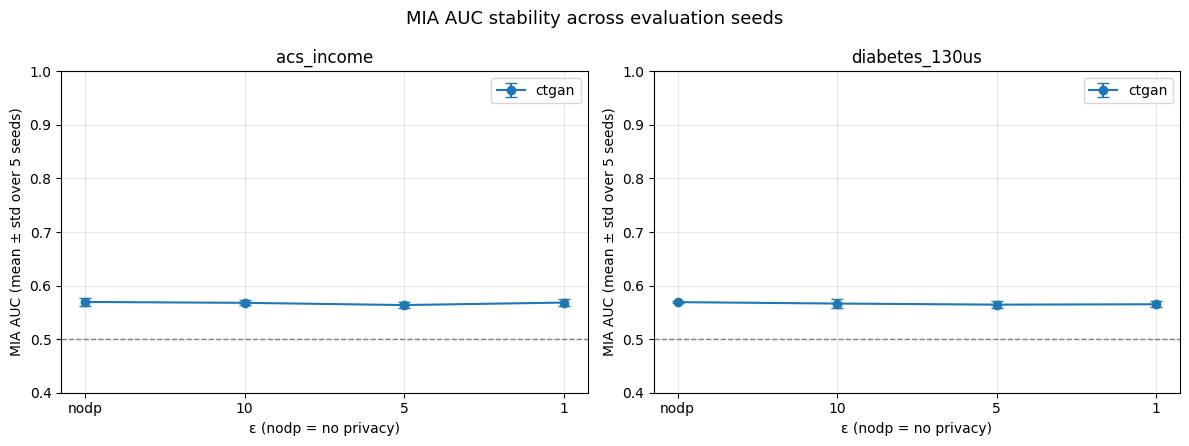

In [15]:
import matplotlib.pyplot as plt

datasets_present = sorted(stability_df['dataset'].unique())
fig, axes = plt.subplots(1, len(datasets_present), figsize=(6 * len(datasets_present), 4.5), squeeze=False)

for col, dataset_name in enumerate(datasets_present):
    ax = axes[0][col]
    for gen_name, group in stability_df[stability_df['dataset'] == dataset_name].groupby('generator'):
        g = group.set_index('epsilon').reindex(eps_order)
        ax.errorbar(eps_order, g['mia_auc_mean'], yerr=g['mia_auc_std'],
                    marker='o', capsize=4, label=gen_name)
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)
    ax.set_title(dataset_name)
    ax.set_xlabel('ε (nodp = no privacy)')
    ax.set_ylabel('MIA AUC (mean ± std over 5 seeds)')
    ax.set_ylim(0.4, 1.0)
    ax.grid(alpha=0.3)
    ax.legend()

fig.suptitle('MIA AUC stability across evaluation seeds', fontsize=13)
fig.tight_layout()

out_path = Path(config['reporting']['plots']['tradeoff_curves']) / 'mia_seed_stability.png'
out_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_path, dpi=150)
print(f'Saved {out_path}')
plt.show()